<a href="https://colab.research.google.com/github/Prab999/Machine-Learning-with-scikit-learn/blob/main/AmesHousing_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
ames_df = pd.read_csv('AmesHousing.csv')
ames_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
#Pre-Processing

#find missing percentages for every column
missing_percentages = ames_df.isnull().mean() * 100

#show columns with missing values
missing_data = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print("Columns with Missing Data (Percentages):")
print(missing_data)

Columns with Missing Data (Percentages):
Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


In [ ]:
# Drop features with > 50% missing values
cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type']
ames_df.drop(columns=cols_to_drop, inplace=True)

# Non-Random Missing Values
# columns where nan means missing feature
categorical_none = ['Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Garage Finish', 'Garage Type',
                    'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Cond', 'Bsmt Qual', 'BsmtFin Type 1']
ames_df[categorical_none] = ames_df[categorical_none].fillna('None')

# columns where NaN means that the house doesn't have it
numerical_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars',
                  'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2',
                  'Total Bsmt SF', 'Bsmt Unf SF', 'Mas Vnr Area']
ames_df[numerical_zero] = ames_df[numerical_zero].fillna(0)

# Univariate Imputation for random missing data
# Replaces with median
ames_df['Lot Frontage'] = ames_df['Lot Frontage'].fillna(ames_df['Lot Frontage'].median())

# Listwise Deletion leftover random missing value
# Drop any remaining rows containing missing values
ames_df.dropna(inplace=True)

# Verify dataset is clean
print("Remaining missing values:", ames_df.isnull().sum().sum())
print("Cleaned Data Shape:", ames_df.shape)

Remaining missing values: 0
Cleaned Data Shape: (2929, 77)


In [ ]:
# Look for text features for encoding
categorical_cols = ames_df.select_dtypes(include=['object']).columns
numerical_cols = ames_df.select_dtypes(exclude=['object']).columns

print(f"Number of Categorical Columns: {len(categorical_cols)}")
print(f"Number of Numerical Columns: {len(numerical_cols)}")

print("\n Categorical Columns to Encode:")
print(categorical_cols[:5].tolist())

Number of Categorical Columns: 38
Number of Numerical Columns: 39

 Categorical Columns to Encode:
['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities']


In [ ]:
# One-Hot Encoding on all categorical columns
ames_encoded = pd.get_dummies(ames_df, columns=categorical_cols, drop_first=True)

# Verify new shape
print(f"Data Shape after One-Hot Encoding: {ames_encoded.shape}")

# Separate the Target from the Features
X_ames = ames_encoded.drop('SalePrice', axis=1)
y_ames = ames_encoded['SalePrice']

# Create Train/Test Split
from sklearn.model_selection import train_test_split
X_train_ames, X_test_ames, y_train_ames, y_test_ames = train_test_split(
    X_ames, y_ames, test_size=0.2, random_state=42
)

# Scale the Features, primarily for Elastic Net
from sklearn.preprocessing import StandardScaler
scaler_ames = StandardScaler()
X_train_ames_scaled = scaler_ames.fit_transform(X_train_ames)
X_test_ames_scaled = scaler_ames.transform(X_test_ames)

print("\nAmes Housing Data Pipeline Complete. Ready for Modeling.")

Data Shape after One-Hot Encoding: (2929, 259)

Ames Housing Data Pipeline Complete. Ready for Modeling.


In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linearModel = LinearRegression()
linearModel.fit(X_train_ames_scaled, y_train_ames)

#predictions on test
y_pred_lin = linearModel.predict(X_test_ames_scaled)

#regression metrics
mae_lin = mean_absolute_error(y_test_ames, y_pred_lin)
mse_lin = mean_squared_error(y_test_ames, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test_ames, y_pred_lin)

train_score_lin = linearModel.score(X_train_ames_scaled, y_train_ames)
print(f"Training R-squared: {train_score_lin:.4f}")

print(f"MAE:  ${mae_lin:,.2f}")
print(f"MSE:  {mse_lin:,.2f}")
print(f"RMSE: ${rmse_lin:,.2f}")
print(f"R-squared: {r2_lin:.4f}")

Training R-squared: 0.9310
MAE:  $15,960.52
MSE:  1,014,798,302.22
RMSE: $31,855.90
R-squared: 0.8660


In [ ]:
#Elastic Net
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

#Tuning grid, l1_ratio (testing mix of l1 and l2 reg.), and penalty
param_grid_en = {
    'alpha': [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5], # centered around 1, prev best, then updated to measure around .5
    'l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5], #centered around .5 which waas previous best, then updated as .3
    'max_iter': [50000],
    'tol': [0.001]
}

#run with 5 folds
grid_search_en = GridSearchCV(
    ElasticNet(),
    param_grid_en,
    cv=5,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1 # Uses all available CPU cores in Colab to speed this up!
)

grid_search_en.fit(X_train_ames_scaled, y_train_ames)

print("Best Parameters:", grid_search_en.best_params_)
print(f"Best CV R-squared: {grid_search_en.best_score_:.4f}")

Best Parameters: {'alpha': 0.4, 'l1_ratio': 0.1, 'max_iter': 50000, 'tol': 0.001}
Best CV R-squared: 0.8555


In [ ]:
#Using best model after tuning, .5 l1_ratio, alpha:1
best_en_model = grid_search_en.best_estimator_
y_pred_en = best_en_model.predict(X_test_ames_scaled)

mae_en = mean_absolute_error(y_test_ames, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_test_ames, y_pred_en))
r2_en = r2_score(y_test_ames, y_pred_en)

train_score_en = best_en_model.score(X_train_ames_scaled, y_train_ames)
print(f"Training R-squared: {train_score_en:.4f}")

print(f"\n--- Elastic Net Final Test Metrics ---")
print(f"MAE:  ${mae_en:,.2f}")
print(f"RMSE: ${rmse_en:,.2f}")
print(f"R-squared: {r2_en:.4f}")

Training R-squared: 0.8956

--- Elastic Net Final Test Metrics ---
MAE:  $16,751.20
RMSE: $32,703.40
R-squared: 0.8588


In [ ]:
#Deep Net, Multi-Layer Perceptron
from sklearn.neural_network import MLPRegressor
import time

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64), # Two hidden layers: 128 nodes, then 64 nodes
    activation='relu',            # reLu for regression
    solver='adam',                # Best for general optimization
    max_iter=1000,
    random_state=42
)

# Time the training process
start_time = time.time()
mlp_model.fit(X_train_ames_scaled, y_train_ames)
print(f"MLP Training Time: {time.time() - start_time:.2f} seconds")

# Predict on both Train and Test to check for overfitting
y_pred_mlp_train = mlp_model.predict(X_train_ames_scaled)
y_pred_mlp_test = mlp_model.predict(X_test_ames_scaled)

# Calculate Metrics
r2_mlp_train = r2_score(y_train_ames, y_pred_mlp_train)
r2_mlp_test = r2_score(y_test_ames, y_pred_mlp_test)
mae_mlp = mean_absolute_error(y_test_ames, y_pred_mlp_test)
rmse_mlp = np.sqrt(mean_squared_error(y_test_ames, y_pred_mlp_test))

print(f"Training R-squared: {r2_mlp_train:.4f}")
print(f"Test R-squared:     {r2_mlp_test:.4f}")
print(f"Test MAE:           ${mae_mlp:,.2f}")
print(f"Test RMSE:          ${rmse_mlp:,.2f}")

MLP Training Time: 68.88 seconds
Training R-squared: 0.9654
Test R-squared:     0.8138
Test MAE:           $18,795.44
Test RMSE:          $37,548.18


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Tuning current Deep MLP overfitting to training
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)], # Testing simpler architectures
    'alpha': [0.1, 1.0, 5.0, 10.0],                             # L2 regularization
    'max_iter': [2000]
}

grid_search_mlp = GridSearchCV(
    MLPRegressor(activation='relu', solver='adam', random_state=42),
    param_grid_mlp,
    cv=5,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)

print("Starting MLP Grid Search...")
grid_search_mlp.fit(X_train_ames_scaled, y_train_ames)

print("\nBest MLP Parameters:", grid_search_mlp.best_params_)

Starting MLP Grid Search... (Grab a coffee, this will take a few minutes)

Best MLP Parameters: {'alpha': 10.0, 'hidden_layer_sizes': (64, 32), 'max_iter': 2000}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Eval
best_mlp = grid_search_mlp.best_estimator_
y_pred_mlp_test_tuned = best_mlp.predict(X_test_ames_scaled)
y_pred_mlp_train_tuned = best_mlp.predict(X_train_ames_scaled)

r2_mlp_train_tuned = r2_score(y_train_ames, y_pred_mlp_train_tuned)
r2_mlp_test_tuned = r2_score(y_test_ames, y_pred_mlp_test_tuned)
mae_mlp_tuned = mean_absolute_error(y_test_ames, y_pred_mlp_test_tuned)
rmse_mlp_tuned = np.sqrt(mean_squared_error(y_test_ames, y_pred_mlp_test_tuned))

#best model: 'alpha': 10.0, 'hidden_layer_sizes': (64, 32)
print(f"\n--- Tuned MLP Final Metrics ---")
print(f"Training R-squared: {r2_mlp_train_tuned:.4f}")
print(f"Test R-squared:     {r2_mlp_test_tuned:.4f}")
print(f"Test MAE:           ${mae_mlp_tuned:,.2f}")
print(f"Test RMSE:          ${rmse_mlp_tuned:,.2f}")


--- Tuned MLP Final Metrics ---
Training R-squared: 0.9754
Test R-squared:     0.8306
Test MAE:           $18,266.00
Test RMSE:          $35,814.47


In [ ]:
#model with best parameters:
final_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    alpha=10.0,
    max_iter=2000,
    activation='relu',
    solver='adam',
    random_state=42
)
final_mlp.fit(X_train_ames_scaled, y_train_ames)

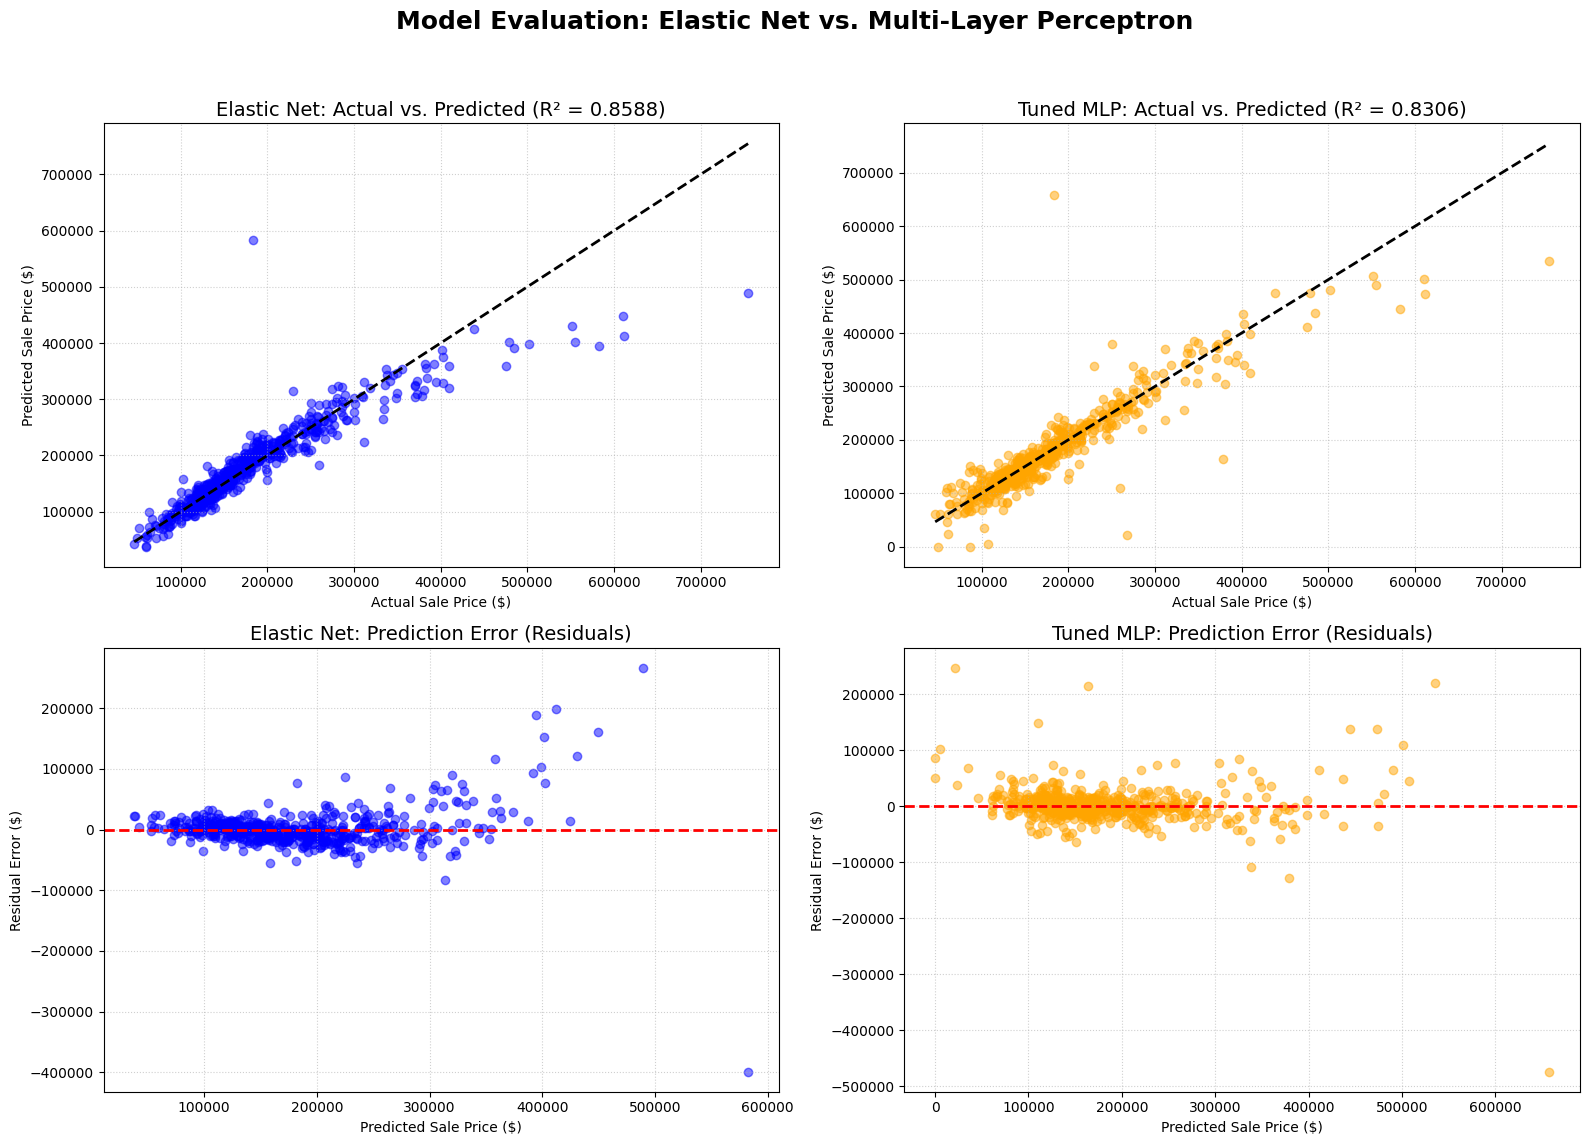

In [ ]:
#graphs:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Evaluation: Elastic Net vs. Multi-Layer Perceptron', fontsize=18, fontweight='bold')

# --- Plot 1: Elastic Net (Actual vs. Predicted) ---
axes[0, 0].scatter(y_test_ames, y_pred_en, alpha=0.5, color='blue')
axes[0, 0].plot([y_test_ames.min(), y_test_ames.max()], [y_test_ames.min(), y_test_ames.max()], 'k--', lw=2) # Diagonal line
axes[0, 0].set_title(f'Elastic Net: Actual vs. Predicted (R² = {r2_en:.4f})', fontsize=14)
axes[0, 0].set_xlabel('Actual Sale Price ($)')
axes[0, 0].set_ylabel('Predicted Sale Price ($)')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: MLP (Actual vs. Predicted) ---
axes[0, 1].scatter(y_test_ames, y_pred_mlp_test_tuned, alpha=0.5, color='orange')
axes[0, 1].plot([y_test_ames.min(), y_test_ames.max()], [y_test_ames.min(), y_test_ames.max()], 'k--', lw=2)
axes[0, 1].set_title(f'Tuned MLP: Actual vs. Predicted (R² = {r2_mlp_test_tuned:.4f})', fontsize=14)
axes[0, 1].set_xlabel('Actual Sale Price ($)')
axes[0, 1].set_ylabel('Predicted Sale Price ($)')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- Plot 3: Elastic Net (Residuals)
residuals_en = y_test_ames - y_pred_en
axes[1, 0].scatter(y_pred_en, residuals_en, alpha=0.5, color='blue')
axes[1, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 0].set_title('Elastic Net: Prediction Error (Residuals)', fontsize=14)
axes[1, 0].set_xlabel('Predicted Sale Price ($)')
axes[1, 0].set_ylabel('Residual Error ($)')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# --- Plot 4: MLP (Residuals)
residuals_mlp = y_test_ames - y_pred_mlp_test_tuned
axes[1, 1].scatter(y_pred_mlp_test_tuned, residuals_mlp, alpha=0.5, color='orange')
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('Tuned MLP: Prediction Error (Residuals)', fontsize=14)
axes[1, 1].set_xlabel('Predicted Sale Price ($)')
axes[1, 1].set_ylabel('Residual Error ($)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()